# Polynomial Regression From Scratch

Polynomial Regression is a supervised machine learning technique used to model
nonlinear relationships between input features and a continuous target variable.

Unlike ordinary Linear Regression, Polynomial Regression introduces higher-order
terms of the input features, allowing the model to learn curved relationships.

In this notebook, Polynomial Regression will be implemented from scratch using
Python and NumPy.

The implementation will include:

- Generating a nonlinear dataset
- Polynomial feature transformation from scratch
- Linear Regression from scratch
- Gradient Descent optimization
- Model prediction
- Regression evaluation metrics
- Visualization of the fitted polynomial curve
- Comparison with Scikit-Learn
- Experiments with different polynomial degrees

## Learning Objectives

By completing this notebook, we will understand:

1. Why Polynomial Regression is needed
2. How polynomial features are created
3. How Gradient Descent trains the model
4. How polynomial degree affects model complexity
5. How to detect underfitting and overfitting
6. How a from-scratch implementation compares with Scikit-Learn

## 1. Mathematical Intuition

Ordinary Linear Regression models the relationship between an input $x$ and
target $y$ as:

$$
y = w_0 + w_1x
$$

This produces a straight line.

However, many real-world relationships are nonlinear. Polynomial Regression
extends the model by adding powers of the input feature.

For a second-degree polynomial:

$$
y = w_0 + w_1x + w_2x^2
$$

For a third-degree polynomial:

$$
y = w_0 + w_1x + w_2x^2 + w_3x^3
$$

More generally:

$$
y = w_0 + w_1x + w_2x^2 + \cdots + w_dx^d
$$

where $d$ represents the polynomial degree.

Although the relationship between the original feature and target is nonlinear,
the model remains linear with respect to its parameters $w_0, w_1, ..., w_d$.

The objective is to find the parameters that minimize Mean Squared Error (MSE):

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Gradient Descent is used to optimize these parameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

## 2. Generate a Nonlinear Dataset

To clearly demonstrate Polynomial Regression, we will create a synthetic
dataset with a nonlinear relationship.

The underlying relationship will approximately follow:

$$
y = 3x^2 + 2x + 5
$$

Random noise will be added to make the problem more realistic.

A fixed random seed is used so that the experiment can be reproduced.

In [2]:
np.random.seed(42)

# Generate input values
X = np.linspace(-5, 5, 200).reshape(-1, 1)

# Generate nonlinear target values
noise = np.random.normal(0, 5, size=X.shape)

y = 3 * X**2 + 2 * X + 5 + noise

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 1)
y shape: (200, 1)


In [3]:
print("First 10 X values:")
print(X[:10])

print("\nFirst 10 y values:")
print(y[:10])

First 10 X values:
[[-5.        ]
 [-4.94974874]
 [-4.89949749]
 [-4.84924623]
 [-4.79899497]
 [-4.74874372]
 [-4.69849246]
 [-4.64824121]
 [-4.59798995]
 [-4.54773869]]

First 10 y values:
[[72.48357077]
 [67.90921888]
 [70.4546746 ]
 [73.46222385]
 [63.32230148]
 [61.98352849]
 [69.72657341]
 [64.35913016]
 [56.8811829 ]
 [60.6631045 ]]


In [4]:
data = pd.DataFrame({
    "Feature": X.flatten(),
    "Target": y.flatten()
})

data.head(10)

,Feature,Target
0,-5.000000,72.483571
1,-4.949749,67.909219
2,-4.899497,70.454675
3,-4.849246,73.462224
4,-4.798995,63.322301
5,-4.748744,61.983528
6,-4.698492,69.726573
7,-4.648241,64.359130
8,-4.597990,56.881183
9,-4.547739,60.663105


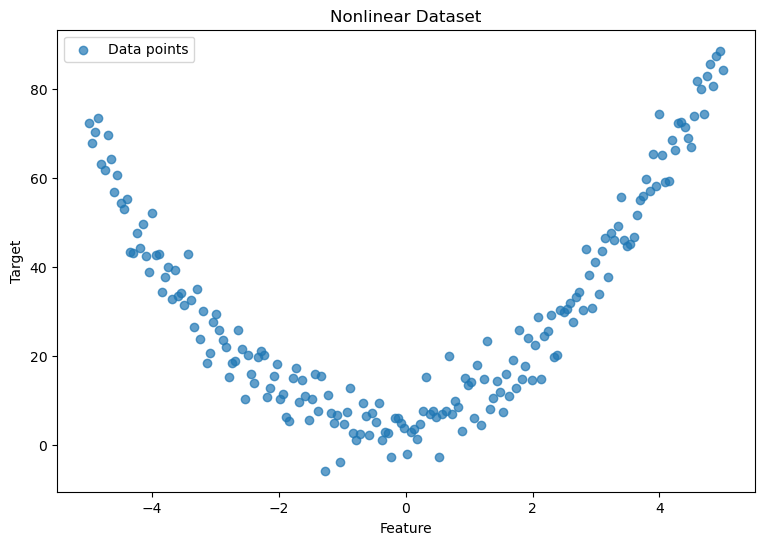

In [5]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y,
    alpha=0.7,
    label="Data points"
)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Nonlinear Dataset")
plt.legend()

plt.show()

### Observation

The plotted data does not follow a straight-line relationship.

Instead, the target values form a curved pattern. A simple Linear Regression
model would therefore struggle to capture the relationship accurately.

Polynomial Regression can address this problem by adding higher-order feature
terms such as $x^2$, $x^3$, and so on.

## 3. Train/Test Split

The dataset will be divided into:

- 80% training data
- 20% testing data

The model will learn its parameters using only the training data.

The test data will then be used to evaluate how well the model generalizes to
previously unseen observations.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


## 4. Polynomial Feature Transformation From Scratch

Polynomial Regression requires transforming the original feature into
polynomial features.

For example, if:

$$
X = [x]
$$

and the degree is 3, the transformed representation becomes:

$$
X_{poly} = [x, x^2, x^3]
$$

The intercept term will be handled separately by our regression model.

We will implement this transformation ourselves instead of using
Scikit-Learn's `PolynomialFeatures`.

In [7]:
def polynomial_features(X, degree):
    """
    Transform input features into polynomial features.

    Parameters
    ----------
    X : numpy.ndarray
        Input feature matrix.

    degree : int
        Maximum polynomial degree.

    Returns
    -------
    numpy.ndarray
        Polynomial feature matrix.
    """

    features = []

    for d in range(1, degree + 1):
        features.append(X ** d)

    return np.hstack(features)

In [8]:
X_example = np.array([
    [1],
    [2],
    [3]
])

X_poly_example = polynomial_features(
    X_example,
    degree=3
)

print(X_poly_example)

[[ 1  1  1]
 [ 2  4  8]
 [ 3  9 27]]


In [9]:
degree = 2

X_train_poly = polynomial_features(
    X_train,
    degree
)

X_test_poly = polynomial_features(
    X_test,
    degree
)

print("Original training shape:", X_train.shape)
print("Polynomial training shape:", X_train_poly.shape)

print("\nFirst 5 polynomial feature rows:")
print(X_train_poly[:5])

Original training shape: (160, 1)
Polynomial training shape: (160, 2)

First 5 polynomial feature rows:
[[-1.03015075  1.06121058]
 [ 4.89949749 24.00507563]
 [-3.09045226  9.55089518]
 [-3.79396985 14.39420722]
 [ 1.13065327  1.27837681]]


## 5. Linear Regression Model From Scratch

After polynomial transformation, the problem becomes a Linear Regression
problem over the transformed features.

For degree 2:

$$
\hat{y} = w_0 + w_1x + w_2x^2
$$

For degree 3:

$$
\hat{y} = w_0 + w_1x + w_2x^2 + w_3x^3
$$

We will implement Linear Regression using Gradient Descent.

The parameters are updated using:

$$
w := w - \alpha \frac{\partial MSE}{\partial w}
$$

and:

$$
b := b - \alpha \frac{\partial MSE}{\partial b}
$$

where $\alpha$ is the learning rate.

In [10]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.001, iterations=5000):
        self.learning_rate = learning_rate
        self.iterations = iterations

        self.weights = None
        self.bias = None

        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        # Flatten target
        y = y.flatten()

        for i in range(self.iterations):

            # Forward pass
            y_pred = np.dot(X, self.weights) + self.bias

            # Error
            error = y_pred - y

            # Gradients
            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            # Parameter updates
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate loss
            mse = np.mean(error ** 2)

            self.loss_history.append(mse)

        return self

    def predict(self, X):

        return np.dot(X, self.weights) + self.bias

## 6. Train the Polynomial Regression Model

We will now train our from-scratch model using the degree-2 polynomial
features.

The model will learn:

$$
\hat{y} = w_0 + w_1x + w_2x^2
$$

In [11]:
model = LinearRegressionScratch(
    learning_rate=0.001,
    iterations=5000
)

model.fit(
    X_train_poly,
    y_train
)

print("Model training completed.")

Model training completed.


In [12]:
print("Bias:", model.bias)

print("Weights:")
for i, weight in enumerate(model.weights, start=1):
    print(f"w{i}: {weight}")

Bias: 4.5729500106754255
Weights:
w1: 2.0842922800752643
w2: 3.0099790231868195


In [13]:
y_pred = model.predict(X_test_poly)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[ 4.25554313 49.99392685 34.00723384 36.71185956 13.73171324  8.02247758
  8.44904351 49.73470374 54.56210077 21.44088517]


## 7. Model Evaluation

We will evaluate the model using three common regression metrics:

### Mean Squared Error (MSE)

$$
MSE = \frac{1}{n}\sum(y_i-\hat{y}_i)^2
$$

Lower values indicate smaller prediction errors.

### Mean Absolute Error (MAE)

$$
MAE = \frac{1}{n}\sum|y_i-\hat{y}_i|
$$

MAE represents the average absolute prediction error.

### R² Score

R² measures how much of the variation in the target variable is explained
by the model.

A value closer to 1 generally indicates better predictive performance.

In [15]:
mse = mean_squared_error(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

MSE: 19.4447
MAE: 3.6777
R² Score: 0.9495


In [16]:
results = pd.DataFrame({
    "Actual": y_test.flatten(),
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,-2.616431,4.255543
1,47.787537,49.993927
2,31.598421,34.007234
3,30.848361,36.711860
4,14.515832,13.731713
5,9.885555,8.022478
6,5.756245,8.449044
7,45.290313,49.734704
8,55.917178,54.562101
9,18.424718,21.440885


## 8. Visualize the Polynomial Regression Curve

The test observations are unordered, so we first sort the input values.

We then plot:

- Actual observations
- Polynomial Regression predictions

In [18]:
sorted_indices = np.argsort(
    X_test[:, 0]
)

X_test_sorted = X_test[sorted_indices]
y_test_sorted = y_test.flatten()[sorted_indices]

X_test_poly_sorted = polynomial_features(
    X_test_sorted,
    degree
)

y_pred_sorted = model.predict(
    X_test_poly_sorted
)

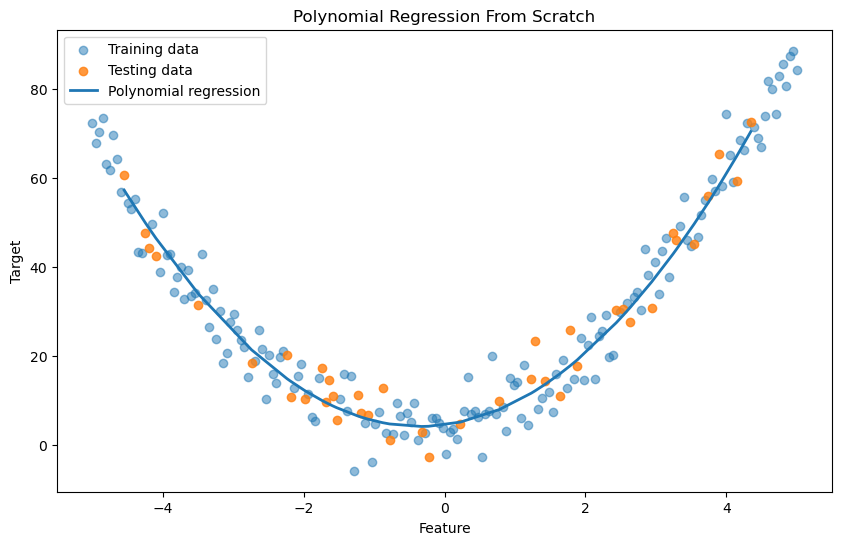

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_train,
    y_train,
    alpha=0.5,
    label="Training data"
)

plt.scatter(
    X_test,
    y_test,
    alpha=0.8,
    label="Testing data"
)

plt.plot(
    X_test_sorted,
    y_pred_sorted,
    linewidth=2,
    label="Polynomial regression"
)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Polynomial Regression From Scratch")

plt.legend()

plt.show()

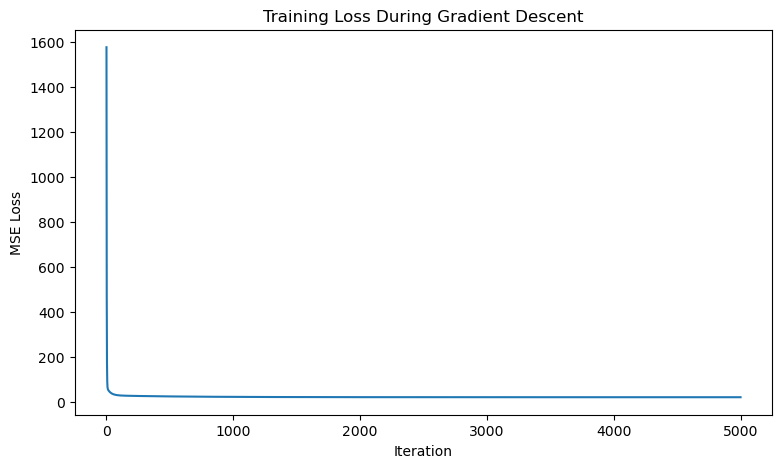

In [20]:
plt.figure(figsize=(9, 5))

plt.plot(
    model.loss_history
)

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss During Gradient Descent")

plt.show()

### Interpretation

The training loss should generally decrease as Gradient Descent updates the
model parameters.

A decreasing loss indicates that the optimization process is learning
parameters that produce increasingly smaller prediction errors.

If the loss becomes unstable or increases significantly, the learning rate
may be too large.

## 9. Compare With Scikit-Learn

We will now implement the same polynomial regression workflow using
Scikit-Learn.

Important:

The purpose of this comparison is not to replace our implementation.

Instead, it provides a useful reference for validating the correctness of
the from-scratch implementation.

Our implementation created polynomial features manually.

Scikit-Learn provides the `PolynomialFeatures` transformer for the same task.

In [21]:
sklearn_poly = PolynomialFeatures(
    degree=degree,
    include_bias=False
)

X_train_poly_sklearn = sklearn_poly.fit_transform(
    X_train
)

X_test_poly_sklearn = sklearn_poly.transform(
    X_test
)

print("Scikit-Learn polynomial feature shape:")
print(X_train_poly_sklearn.shape)

Scikit-Learn polynomial feature shape:
(160, 2)


In [22]:
print(
    "Maximum difference between implementations:",
    np.max(
        np.abs(
            X_train_poly -
            X_train_poly_sklearn
        )
    )
)

Maximum difference between implementations: 0.0


In [23]:
sklearn_model = LinearRegression()

sklearn_model.fit(
    X_train_poly_sklearn,
    y_train
)

sklearn_predictions = sklearn_model.predict(
    X_test_poly_sklearn
)

In [24]:
scratch_mse = mean_squared_error(
    y_test,
    y_pred
)

scratch_mae = mean_absolute_error(
    y_test,
    y_pred
)

scratch_r2 = r2_score(
    y_test,
    y_pred
)


sklearn_mse = mean_squared_error(
    y_test,
    sklearn_predictions
)

sklearn_mae = mean_absolute_error(
    y_test,
    sklearn_predictions
)

sklearn_r2 = r2_score(
    y_test,
    sklearn_predictions
)


comparison = pd.DataFrame({
    "Model": [
        "Polynomial Regression From Scratch",
        "Scikit-Learn Polynomial Regression"
    ],
    "MSE": [
        scratch_mse,
        sklearn_mse
    ],
    "MAE": [
        scratch_mae,
        sklearn_mae
    ],
    "R2 Score": [
        scratch_r2,
        sklearn_r2
    ]
})

comparison

,Model,MSE,MAE,R2 Score
0,Polynomial Regression From Scratch,19.444713,3.677692,0.949464
1,Scikit-Learn Polynomial Regression,19.370247,3.671553,0.949657


In [26]:
degrees = range(1, 11)

experiment_results = []

for degree_value in degrees:

    # Create polynomial features
    X_train_poly_exp = polynomial_features(
        X_train,
        degree_value
    )

    X_test_poly_exp = polynomial_features(
        X_test,
        degree_value
    )

    # Standardize polynomial features
    mean = np.mean(X_train_poly_exp, axis=0)
    std = np.std(X_train_poly_exp, axis=0)

    # Prevent division by zero
    std[std == 0] = 1

    X_train_scaled = (
        X_train_poly_exp - mean
    ) / std

    X_test_scaled = (
        X_test_poly_exp - mean
    ) / std

    # Train model
    experiment_model = LinearRegressionScratch(
        learning_rate=0.01,
        iterations=5000
    )

    experiment_model.fit(
        X_train_scaled,
        y_train
    )

    # Predictions
    train_predictions = experiment_model.predict(
        X_train_scaled
    )

    test_predictions = experiment_model.predict(
        X_test_scaled
    )

    # Metrics
    train_mse = mean_squared_error(
        y_train,
        train_predictions
    )

    test_mse = mean_squared_error(
        y_test,
        test_predictions
    )

    train_r2 = r2_score(
        y_train,
        train_predictions
    )

    test_r2 = r2_score(
        y_test,
        test_predictions
    )

    experiment_results.append({
        "Degree": degree_value,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })

In [27]:
degree_results = pd.DataFrame(
    experiment_results
)

degree_results

,Degree,Train MSE,Test MSE,Train R2,Test R2
0,1,565.519235,378.994080,0.061956,0.015005
1,2,22.011871,19.370247,0.963488,0.949657
2,3,21.777732,19.568859,0.963877,0.949141
3,4,21.780721,19.502573,0.963872,0.949313
4,5,21.272117,18.985534,0.964715,0.950657
5,6,21.356749,19.361764,0.964575,0.949679
6,7,21.202378,19.105261,0.964831,0.950346
7,8,21.321973,19.142466,0.964633,0.950249
8,9,21.327456,19.088459,0.964623,0.950390
9,10,21.264286,18.950014,0.964728,0.950749


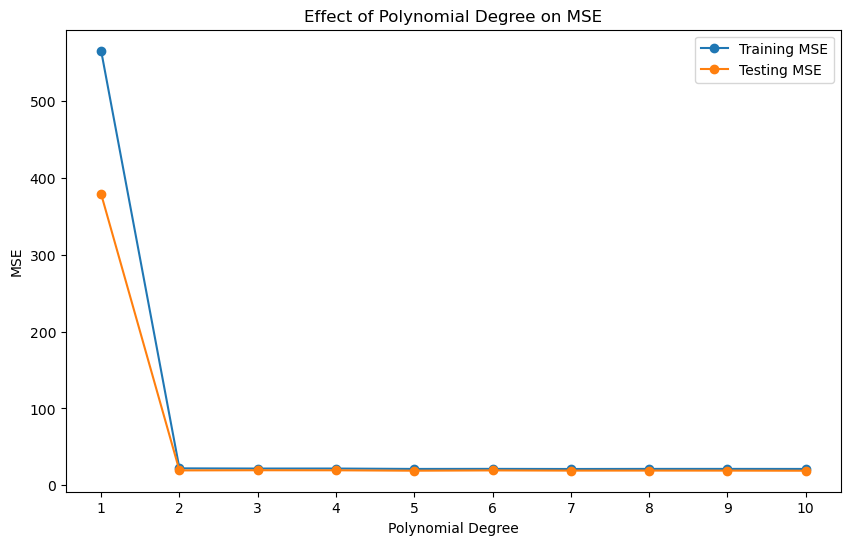

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    degree_results["Degree"],
    degree_results["Train MSE"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    degree_results["Degree"],
    degree_results["Test MSE"],
    marker="o",
    label="Testing MSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Effect of Polynomial Degree on MSE")

plt.xticks(list(degrees))
plt.legend()

plt.show()

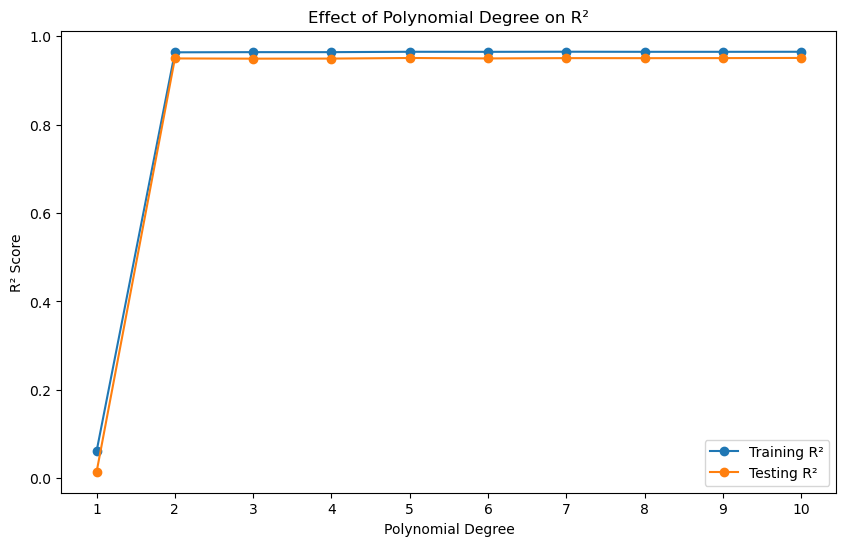

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    degree_results["Degree"],
    degree_results["Train R2"],
    marker="o",
    label="Training R²"
)

plt.plot(
    degree_results["Degree"],
    degree_results["Test R2"],
    marker="o",
    label="Testing R²"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Effect of Polynomial Degree on R²")

plt.xticks(list(degrees))
plt.legend()

plt.show()

In [30]:
best_row = degree_results.loc[
    degree_results["Test MSE"].idxmin()
]

print("Best degree based on test MSE:")
print(int(best_row["Degree"]))

print("\nTest MSE:")
print(best_row["Test MSE"])

print("\nTest R²:")
print(best_row["Test R2"])

Best degree based on test MSE:
10

Test MSE:
18.950013738635075

Test R²:
0.950749429074529


c:\Users\babur\anaconda3\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\babur\AppData\Local\Temp\ipykernel_22828\761213796.py:40: RuntimeWarning: overflow encountered in square
  mse = np.mean(error ** 2)
C:\Users\babur\AppData\Local\Temp\ipykernel_22828\761213796.py:32: RuntimeWarning: overflow encountered in dot
  dw = (2 / n_samples) * np.dot(X.T, error)
C:\Users\babur\AppData\Local\Temp\ipykernel_22828\761213796.py:32: RuntimeWarning: invalid value encountered in dot
  dw = (2 / n_samples) * np.dot(X.T, error)
c:\Users\babur\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\babur\AppData\Local\Temp\ipykernel_22828\761213796.py:36: RuntimeWarning: invalid value encountered in subtract
  self.weights -= self.learning_rate * dw
C:\Users\babur

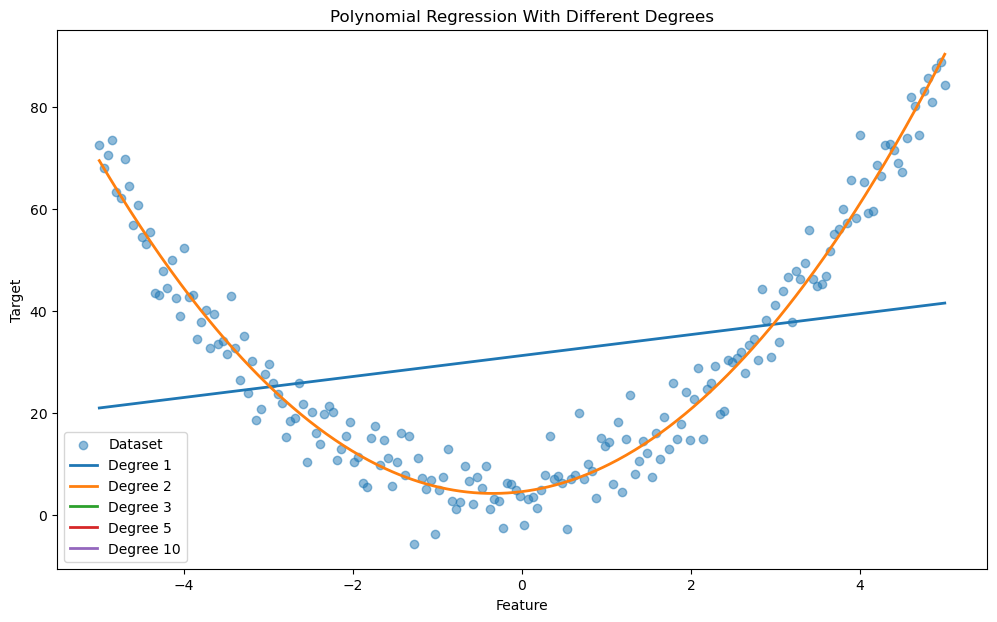

In [31]:
selected_degrees = [1, 2, 3, 5, 10]

X_plot = np.linspace(
    X.min(),
    X.max(),
    500
).reshape(-1, 1)

plt.figure(figsize=(12, 7))

plt.scatter(
    X,
    y,
    alpha=0.5,
    label="Dataset"
)

for degree_value in selected_degrees:

    X_train_poly_degree = polynomial_features(
        X_train,
        degree_value
    )

    X_plot_poly = polynomial_features(
        X_plot,
        degree_value
    )

    degree_model = LinearRegressionScratch(
        learning_rate=0.001,
        iterations=5000
    )

    degree_model.fit(
        X_train_poly_degree,
        y_train
    )

    predictions = degree_model.predict(
        X_plot_poly
    )

    plt.plot(
        X_plot,
        predictions,
        linewidth=2,
        label=f"Degree {degree_value}"
    )

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Polynomial Regression With Different Degrees")

plt.legend()

plt.show()